# Livro para consulta:
- https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.09-pivot-tables.html
    

# 1. Importando bibliotecas <a name="import"></a>

<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# 2. Carregando o dataframe SINASC <a name="read"></a>
<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [3]:
sinasc_raw = pd.read_csv('SINASC_RO_2019.csv')
sinasc_raw.head()

,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,KOTELCHUCK,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,5,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,5,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025


In [5]:
sinasc_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27028 entries, 0 to 27027
Data columns (total 69 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ORIGEM        27028 non-null  int64  
 1   CODESTAB      26913 non-null  float64
 2   CODMUNNASC    27028 non-null  int64  
 3   LOCNASC       27028 non-null  int64  
 4   IDADEMAE      27028 non-null  int64  
 5   ESTCIVMAE     26711 non-null  float64
 6   ESCMAE        26716 non-null  object 
 7   CODOCUPMAE    24121 non-null  float64
 8   QTDFILVIVO    25455 non-null  float64
 9   QTDFILMORT    24930 non-null  float64
 10  CODMUNRES     27028 non-null  int64  
 11  GESTACAO      25796 non-null  object 
 12  GRAVIDEZ      26949 non-null  object 
 13  PARTO         26979 non-null  object 
 14  CONSULTAS     27028 non-null  int64  
 15  DTNASC        27028 non-null  object 
 16  HORANASC      27007 non-null  float64
 17  SEXO          27024 non-null  object 
 18  APGAR1        26932 non-nu

# Tarefa 2

### 1. Crie 2 faixas de Latitude do município (munResLat) sendo uma acima e outra abaixo de -10.5 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [13]:
# Criar as faixas de latitude
sinasc_raw['munResLatFaixa'] = pd.cut(sinasc_raw['munResLat'], bins=[-float('inf'), -10.5, float('inf')], labels=['abaixo de -10.5', 'acima de -10.5'])

# Realizar o groupby e as operações solicitadas para duas variáveis numéricas
result = sinasc_raw.groupby('munResLatFaixa').agg({
    'CONSULTAS': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var'],
    'QTDFILMORT': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
})

print(result)

                CONSULTAS                                               \
                      sum      mean min max median       std       var   
munResLatFaixa                                                           
abaixo de -10.5     48000  3.694297   1   9    4.0  0.643372  0.413928   
acima de -10.5      48662  3.467436   1   9    4.0  0.888240  0.788970   

                QTDFILMORT                                                  
                       sum      mean  min   max median       std       var  
munResLatFaixa                                                              
abaixo de -10.5     3105.0  0.242521  0.0  28.0    0.0  0.599430  0.359317  
acima de -10.5      3538.0  0.291770  0.0   9.0    0.0  0.627856  0.394204  


C:\Users\tiago\AppData\Local\Temp\ipykernel_28052\2321505668.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = sinasc_raw.groupby('munResLatFaixa').agg({


### 2. Crie 2 faixas da área dos municípios (munResArea) sendo uma acima e outra abaixo de 3000 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas


In [15]:
# Criar as faixas de área dos municípios
sinasc_raw['munResAreaFaixa'] = pd.cut(sinasc_raw['munResArea'], bins=[-float('inf'), 3000, float('inf')], labels=['abaixo de 3000', 'acima de 3000'])

# Realizar o groupby e as operações solicitadas para duas variáveis numéricas
result = sinasc_raw.groupby('munResAreaFaixa').agg({
    'SEMAGESTAC': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var'],
    'QTDPARTNOR': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
})

print(result)

                SEMAGESTAC                                                    \
                       sum       mean   min   max median       std       var   
munResAreaFaixa                                                                
abaixo de 3000    197469.0  38.470485  21.0  45.0   39.0  1.874927  3.515350   
acima de 3000     797147.0  38.591547  19.0  45.0   39.0  2.049838  4.201834   

                QTDPARTNOR                                                  
                       sum      mean  min   max median       std       var  
munResAreaFaixa                                                             
abaixo de 3000      1912.0  0.371334  0.0  10.0    0.0  0.856441  0.733490  
acima de 3000      12659.0  0.632982  0.0  41.0    0.0  1.278932  1.635668  


C:\Users\tiago\AppData\Local\Temp\ipykernel_28052\2650738416.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = sinasc_raw.groupby('munResAreaFaixa').agg({


### 3. Determine faixas na variável munResAlt e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [17]:
# Criar as faixas de altitude dos municípios
sinasc_raw['munResAltFaixa'] = pd.cut(sinasc_raw['munResAlt'], bins=[-float('inf'), 200, 400, 600, float('inf')], labels=['abaixo de 200', '200-400', '400-600', 'acima de 600'])

# Realizar o groupby e as operações solicitadas para duas variáveis numéricas
result = sinasc_raw.groupby('munResAltFaixa').agg({
    'APGAR1': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var'],
    'APGAR5': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
})

print(result)

                  APGAR1                                                  \
                     sum      mean  min   max median       std       var   
munResAltFaixa                                                             
abaixo de 200   168862.0  8.140282  0.0  10.0    8.0  0.989649  0.979404   
200-400          35490.0  8.087967  0.0  10.0    8.0  1.013252  1.026680   
400-600          14797.0  8.225125  0.0  10.0    8.0  0.843685  0.711804   
acima de 600         0.0       NaN  NaN   NaN    NaN       NaN       NaN   

                  APGAR5                                                  
                     sum      mean  min   max median       std       var  
munResAltFaixa                                                            
abaixo de 200   190725.0  9.196441  0.0  10.0    9.0  0.784460  0.615377  
200-400          40082.0  9.136540  0.0  10.0    9.0  0.872283  0.760878  
400-600          16332.0  9.083426  1.0  10.0    9.0  0.623008  0.388139  
acima de 600     

C:\Users\tiago\AppData\Local\Temp\ipykernel_28052\384356681.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = sinasc_raw.groupby('munResAltFaixa').agg({


### 4. Plote no mesmo grafico ao longo do tempo a idade media das mulheres de cada regiao imediatas de rondonia


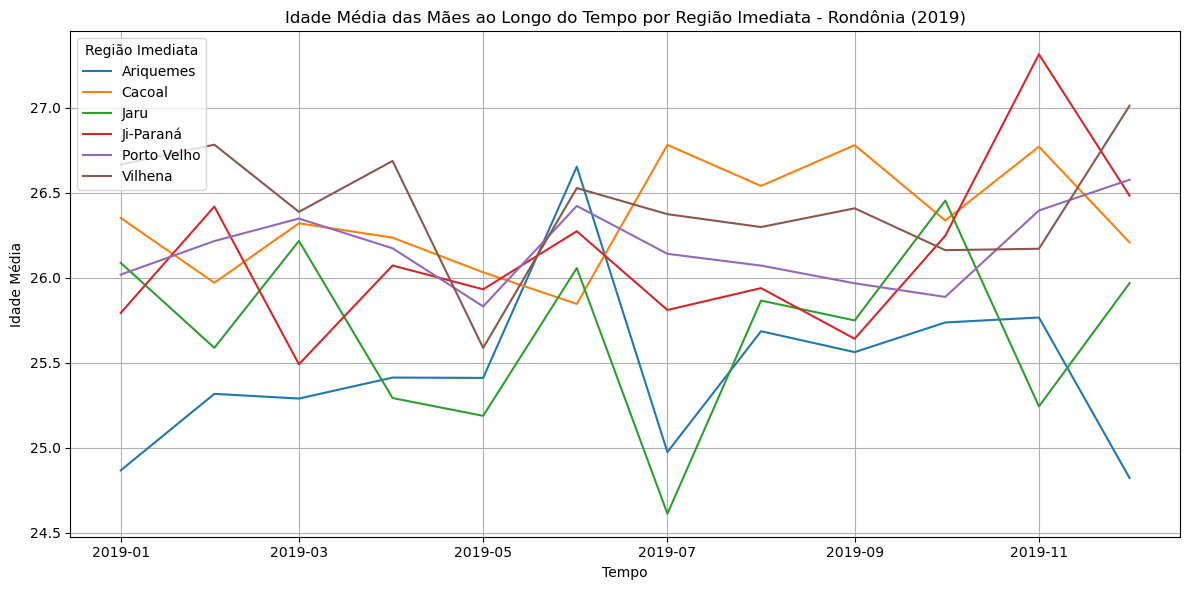

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Mapeamento de regiões imediatas
imediatas = {"Candeias do Jamari": "Porto Velho", "Guajará-Mirim": "Porto Velho", "Itapuã do Oeste": "Porto Velho",
    "Nova Mamoré": "Porto Velho", "Porto Velho": "Porto Velho", "Ariquemes": "Ariquemes",
    "Alto Paraíso": "Ariquemes", "Buritis": "Ariquemes", "Cacaulândia": "Ariquemes",
    "Campo Novo de Rondônia": "Ariquemes", "Cujubim": "Ariquemes", "Monte Negro": "Ariquemes",
    "Rio Crespo": "Ariquemes", "Jaru": "Jaru", "Governador Jorge Teixeira": "Jaru",
    "Machadinho D'Oeste": "Jaru", "Theobroma": "Jaru", "Vale do Anari": "Jaru",
    "Alvorada D'Oeste": "Ji-Paraná", "Costa Marques": "Ji-Paraná", "Ji-Paraná": "Ji-Paraná",
    "Mirante da Serra": "Ji-Paraná", "Nova União": "Ji-Paraná", "Ouro Preto do Oeste": "Ji-Paraná",
    "Presidente Médici": "Ji-Paraná", "São Francisco do Guaporé": "Ji-Paraná",
    "São Miguel do Guaporé": "Ji-Paraná", "Seringueiras": "Ji-Paraná", "Teixeirópolis": "Ji-Paraná",
    "Urupá": "Ji-Paraná", "Vale do Paraíso": "Ji-Paraná", "Município ignorado - RO": "Ji-Paraná",
    "Cacoal": "Cacoal", "Alta Floresta D'Oeste": "Cacoal", "Alto Alegre dos Parecis": "Cacoal",
    "Castanheiras": "Cacoal", "Espigão D'Oeste": "Cacoal", "Ministro Andreazza": "Cacoal",
    "Nova Brasilândia D'Oeste": "Cacoal", "Novo Horizonte do Oeste": "Cacoal",
    "Parecis": "Cacoal", "Pimenta Bueno": "Cacoal", "Primavera de Rondônia": "Cacoal",
    "Rolim de Moura": "Cacoal", "Santa Luzia D'Oeste": "Cacoal", "São Felipe D'Oeste": "Cacoal",
    "Vilhena": "Vilhena", "Cabixi": "Vilhena", "Cerejeiras": "Vilhena", "Chupinguaia": "Vilhena",
    "Colorado do Oeste": "Vilhena", "Corumbiara": "Vilhena", "Pimenteiras do Oeste": "Vilhena"}

# Adicionando a coluna da região imediata
sinasc_raw['regiao_imediata'] = sinasc_raw['munResNome'].map(imediatas)

# Convertendo a data de nascimento para formato de data
sinasc_raw['DTNASC'] = pd.to_datetime(sinasc_raw['DTNASC'])

# Criando coluna do mês e ano para análise temporal
sinasc_raw['ano_mes'] = sinasc_raw['DTNASC'].dt.to_period('M')

# Calculando a idade média por região imediata e mês
idade_media = sinasc_raw.groupby(['ano_mes', 'regiao_imediata'])['IDADEMAE'].mean().unstack()

# Plotando o gráfico
plt.figure(figsize=(12, 6))
for regiao in idade_media.columns:
   plt.plot(idade_media.index.to_timestamp(), idade_media[regiao], label=regiao)

plt.title('Idade Média das Mães ao Longo do Tempo por Região Imediata - Rondônia (2019)')
plt.xlabel('Tempo')
plt.ylabel('Idade Média')
plt.legend(title='Região Imediata')
plt.grid(True)
plt.tight_layout()
plt.show()


### 5. Utilize a tabela do link abaixo e crie faixas utilizando o mapping e gere agrupamentos utilizando essas faixas como chave


In [11]:
# Dicionário de regiões para mapping:
df = pd.read_csv('dados_extras_ro.csv', sep=';', encoding='latin_1')
regioes_map = dict(zip(df['municipio'], df['regiao']))

### 5.1 IDH
A - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IDH-M


In [31]:
IDH = df[['municipio', 'idh']].copy()

def classificador_IDH (idh):
    if idh >= 0.700:
        return 'Alto'
    elif idh < 0.700 and idh >= 0.600:
        return 'Medio'
    else: 
        return 'Baixo'

IDH['categoria'] = IDH['idh'].map(classificador_IDH)

IDH

,municipio,idh,categoria
0,Alta Floresta D'Oeste,0.641,Medio
1,Alto Alegre dos Parecis,0.592,Baixo
2,Alto Paraíso,0.625,Medio
3,Alvorada D'Oeste,0.643,Medio
4,Ariquemes,0.702,Alto
5,Buritis,0.616,Medio
6,Cabixi,0.650,Medio
7,Cacaulândia,0.646,Medio
8,Cacoal,0.718,Alto
9,Campo Novo de Rondônia,0.593,Baixo


In [33]:
# Adicionando a coluna da região imediata
IDH['regiao_imediata'] = IDH['municipio'].map(imediatas)

# Agrupar por categoria de IDH e municipios da região imediata
idh_imediata = IDH.groupby(['regiao_imediata', 'categoria']).size()
idh_imediata

regiao_imediata  categoria
Ariquemes        Alto          1
                 Baixo         1
                 Medio         6
Cacoal           Alto          3
                 Baixo         1
                 Medio        10
Jaru             Baixo         4
                 Medio         1
Ji-Paraná        Alto          1
                 Baixo         2
                 Medio        10
Porto Velho      Alto          1
                 Baixo         1
                 Medio         3
Vilhena          Alto          1
                 Medio         6
dtype: int64

### 5.2 IFDM
B - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IFDM


In [31]:
IFDM = df[['municipio', 'ifdm']].copy()

def classificador_IFDM (ifdm):
    if ifdm >= 0.800:
        return 'Alto'
    elif 0.800 > ifdm >= 0.600:
        return 'Moderado'
    elif 0.600 > ifdm >= 0.400:
        return 'Regular'
    else: 
        return 'Baixo'

IFDM['categoria'] = IFDM['ifdm'].map(classificador_IFDM)
IFDM

,municipio,ifdm,categoria
0,Alta Floresta D'Oeste,0.6337,Moderado
1,Alto Alegre dos Parecis,0.5046,Regular
2,Alto Paraíso,0.5735,Regular
3,Alvorada D'Oeste,0.5919,Regular
4,Ariquemes,0.7746,Moderado
5,Buritis,0.6199,Moderado
6,Cabixi,0.5887,Regular
7,Cacaulândia,0.5721,Regular
8,Cacoal,0.7111,Moderado
9,Campo Novo de Rondônia,0.5272,Regular


### 5.3 PIB
C - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_PIB


In [33]:
PIB = df[['municipio', 'pib']].copy()

def classificador_PIB (pib):
    if pib >= 1000000000:
        return 'Acima de 1 bilhão'
    elif 1000000000 > pib >= 500000000:
        return 'Acima de 500 milhões'
    elif 500000000 > pib >= 300000000:
        return 'Acima de 300 milhões'
    elif 300000000 > pib >= 200000000:
        return 'Acima de 200 milhões'
    elif 200000000 > pib >= 100000000:
        return 'Acima de 100 milhões'
    else: 
        return 'Até 100 milhões'

PIB['categoria'] = PIB['pib'].map(classificador_PIB)
PIB

,municipio,pib,categoria
0,Alta Floresta D'Oeste,496000,Até 100 milhões
1,Alto Alegre dos Parecis,213410,Até 100 milhões
2,Alto Paraíso,358000,Até 100 milhões
3,Alvorada D'Oeste,204098,Até 100 milhões
4,Ariquemes,2579830,Até 100 milhões
5,Buritis,726000,Até 100 milhões
6,Cabixi,113031,Até 100 milhões
7,Cacaulândia,116635,Até 100 milhões
8,Cacoal,2261644,Até 100 milhões
9,Campo Novo de Rondônia,208821,Até 100 milhões


### Analise as respostas encontradas, tire algum insight delas, conte pra gente algo encontrado nos dados.

Exemplo:
- Ah, descobri que a idade mediana das mulheres que deram a luz no ano de 2019 dos municipios com o PIB mais alto é a maior dentre todas.

Um ponto interessante é que em Ji-Paraná, temos que no mês de novembro quando comparado ao ano inteiro, foi essa região imediata que teve mães com a média de idade maior. Além disso, é uma região imediata que tem 10 municípios considerados de médio IDH, regiões imediatas que apresentam mais municípios com maiores índices de IDH parece demonstrar que as mães tenham uma idade maior, conforme observado ao longo do ano.